Pixel resolution : 0.0 × 0.0 m
Pixel area       : 900.0 m²  |  0.0900 ha  |  0.000900 km²
CRS              : EPSG:4326

  UAE LAND COVER CLASSIFICATION — STATISTICS
  Class                Pixels   Area (km²)    Area (ha)        %
  --------------------------------------------------------------
  Urban            16,101,051     14491.08   1449107.85    18.6%
  Vegetation        1,814,721      1633.26    163326.38     2.1%
  Desert           68,536,052     61683.01   6168301.11    79.2%
  Water               106,784        96.11      9610.65     0.1%
  --------------------------------------------------------------
  TOTAL            86,558,608     77903.46   7790345.99   100.0%


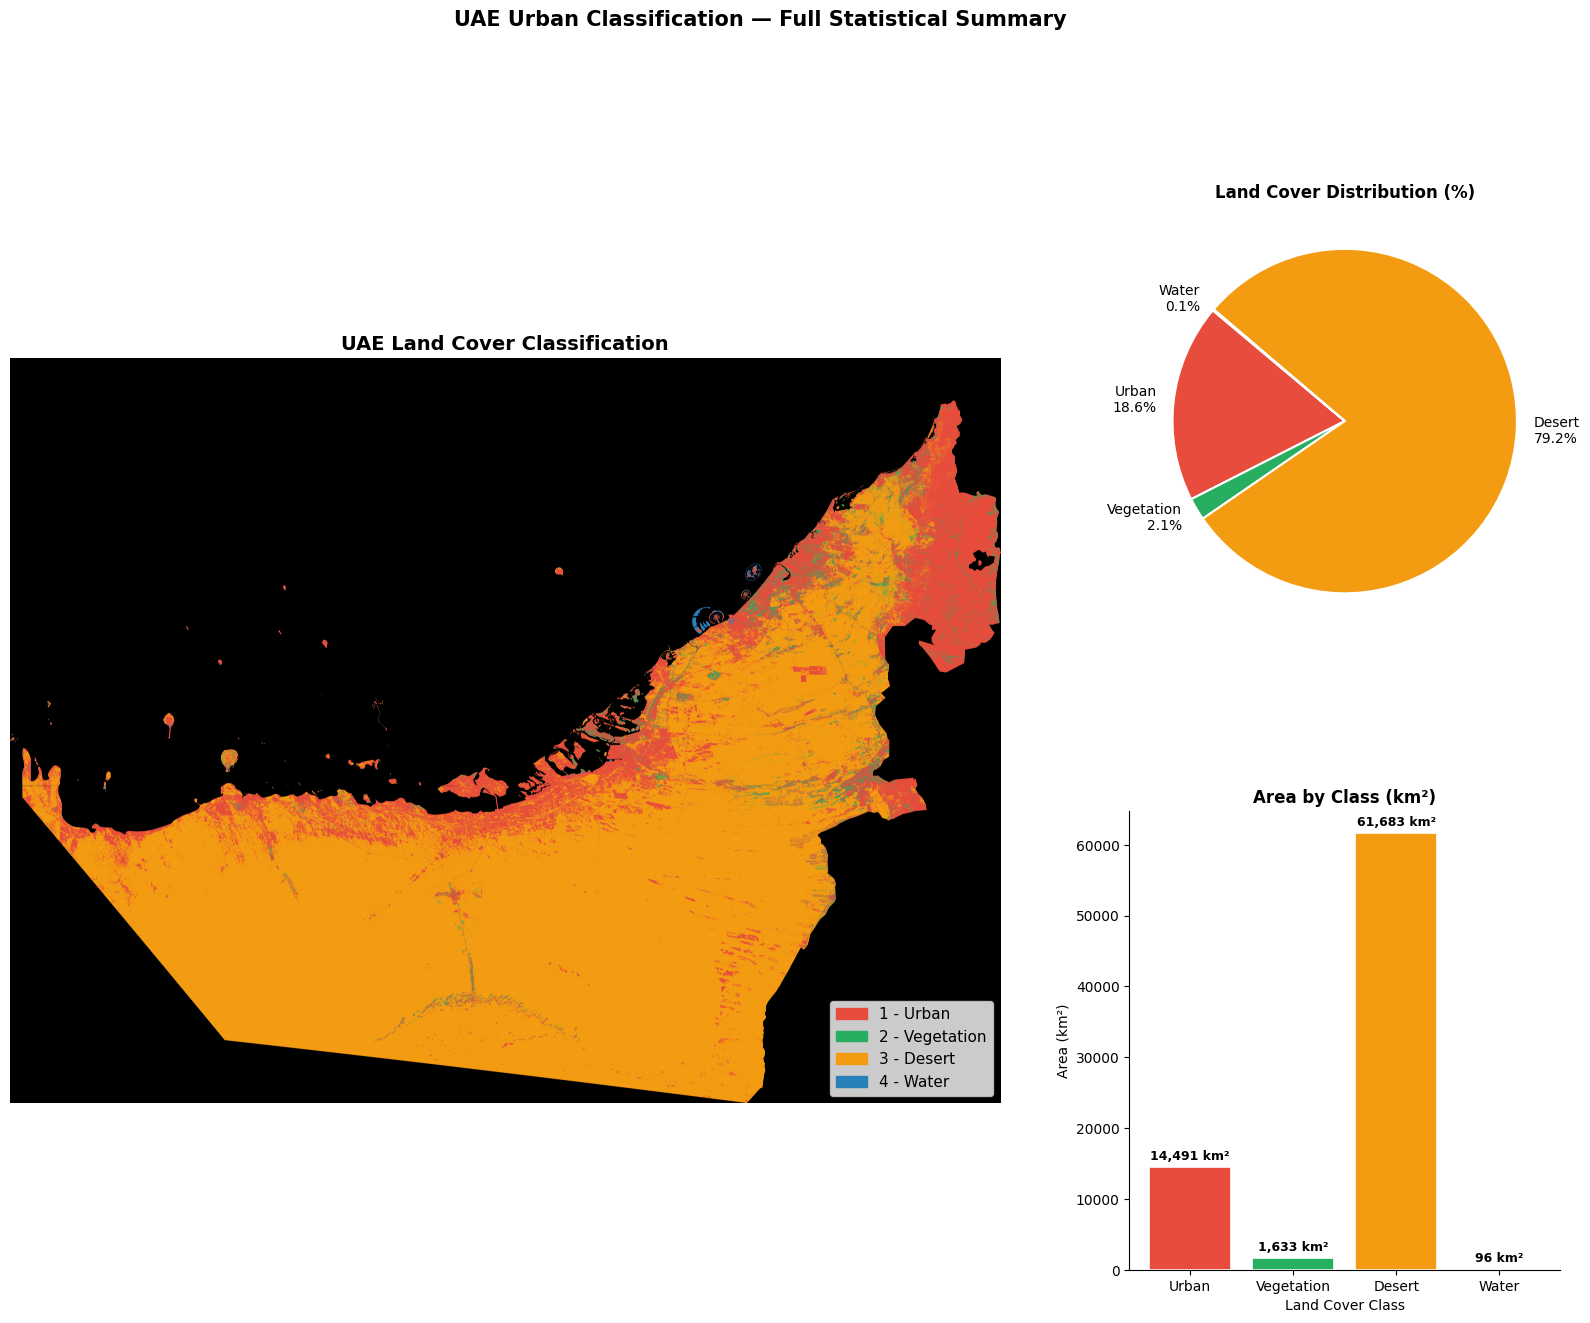

✅ Statistics dashboard saved → /kaggle/working/outputs/07_statistics_dashboard.png

  URBAN ANALYSIS DETAIL
  Urban area              :   14491.08 km²
  Urban area              : 1449107.85 ha
  Urban area              : 14491078472 m²
  Urban % of total area   :      18.6 %
  Urban % of land only    :      18.6 % (excl. water)

  Green cover (Vegetation):    1633.26 km²  (2.1%)
  Water bodies            :      96.11 km²  (0.1%)
  Desert / Bare soil      :   61683.01 km²  (79.2%)

  Total mapped area       :   77903.46 km²


0

In [1]:
# ============================================================
# CELL 13 — Full Classification Statistics
# ============================================================
import numpy as np
import os
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import gc
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ── Load merged classified map ───────────────────────────────
with rasterio.open('/kaggle/input/datasets/saharfeki/2024-image/uae_2024_classified_full_clipped.tif') as src:
    full_map  = src.read(1)
    transform = src.transform
    crs       = src.crs
    pixel_res = src.res   # (pixel_width, pixel_height) in CRS units

# ── Pixel area in m² and km² ────────────────────────────────
# If CRS is projected (meters), pixel_res is in meters
# If CRS is geographic (degrees), convert first
if crs.is_geographic:
    # Approximate: 1 degree ≈ 111,320 meters at equator
    pixel_area_m2  = (pixel_res[0] * 111320) * (pixel_res[1] * 111320)
else:
    pixel_area_m2  = pixel_res[0] * pixel_res[1]  # m²

pixel_area_km2 = pixel_area_m2 / 1_000_000  # km²
pixel_area_ha  = pixel_area_m2 / 10_000      # hectares

print(f"Pixel resolution : {pixel_res[0]:.1f} × {pixel_res[1]:.1f} m")
print(f"Pixel area       : {pixel_area_m2:.1f} m²  |  {pixel_area_ha:.4f} ha  |  {pixel_area_km2:.6f} km²")
print(f"CRS              : {crs}")

# ── Class definitions ────────────────────────────────────────
classes = {
    1: ("Urban",      "#e74c3c"),
    2: ("Vegetation", "#27ae60"),
    3: ("Desert",     "#f39c12"),
    4: ("Water",      "#2980b9"),
}

# ── Count pixels per class ───────────────────────────────────
total_pixels = np.sum(full_map > 0)   # valid pixels only
total_area_km2 = total_pixels * pixel_area_km2

stats = {}
for cid, (cname, color) in classes.items():
    n_pixels  = int(np.sum(full_map == cid))
    area_m2   = n_pixels * pixel_area_m2
    area_ha   = n_pixels * pixel_area_ha
    area_km2  = n_pixels * pixel_area_km2
    pct       = 100 * n_pixels / total_pixels if total_pixels > 0 else 0
    stats[cid] = {
        "name"     : cname,
        "color"    : color,
        "pixels"   : n_pixels,
        "area_m2"  : area_m2,
        "area_ha"  : area_ha,
        "area_km2" : area_km2,
        "pct"      : pct,
    }

# ── Print statistics table ───────────────────────────────────
print(f"\n{'='*70}")
print(f"  UAE LAND COVER CLASSIFICATION — STATISTICS")
print(f"{'='*70}")
print(f"  {'Class':<14} {'Pixels':>12} {'Area (km²)':>12} {'Area (ha)':>12} {'%':>8}")
print(f"  {'-'*62}")

for cid, s in stats.items():
    print(f"  {s['name']:<14} {s['pixels']:>12,} "
          f"{s['area_km2']:>12.2f} "
          f"{s['area_ha']:>12.2f} "
          f"{s['pct']:>7.1f}%")

print(f"  {'-'*62}")
print(f"  {'TOTAL':<14} {total_pixels:>12,} "
      f"{total_area_km2:>12.2f} "
      f"{total_area_km2*100:>12.2f} "
      f"{'100.0%':>8}")
print(f"{'='*70}")

# ── Figures ─────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1 — Classified map
ax_map = fig.add_subplot(gs[:, 0:2])
cmap_final = mcolors.ListedColormap([
    "#000000","#e74c3c","#27ae60","#f39c12","#2980b9"
])
ax_map.imshow(full_map, cmap=cmap_final, vmin=0, vmax=4)
legend_patches = [
    mpatches.Patch(color=s["color"], label=f"{cid} - {s['name']}")
    for cid, s in stats.items()
]
ax_map.legend(handles=legend_patches, loc="lower right", fontsize=11)
ax_map.set_title("UAE Land Cover Classification", fontsize=14, fontweight="bold")
ax_map.axis("off")

# 2 — Pie chart (% area)
ax_pie = fig.add_subplot(gs[0, 2])
pie_values = [s["pct"] for s in stats.values()]
pie_colors = [s["color"] for s in stats.values()]
pie_labels = [f"{s['name']}\n{s['pct']:.1f}%" for s in stats.values()]
wedges, texts = ax_pie.pie(
    pie_values,
    colors=pie_colors,
    labels=pie_labels,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in texts:
    text.set_fontsize(10)
ax_pie.set_title("Land Cover Distribution (%)", fontsize=12, fontweight="bold")

# 3 — Bar chart (area in km²)
ax_bar = fig.add_subplot(gs[1, 2])
names  = [s["name"] for s in stats.values()]
areas  = [s["area_km2"] for s in stats.values()]
colors = [s["color"] for s in stats.values()]
bars   = ax_bar.bar(names, areas, color=colors, edgecolor="white", linewidth=1.2)

# Add value labels on bars
for bar, area in zip(bars, areas):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(areas) * 0.01,
        f"{area:,.0f} km²",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax_bar.set_title("Area by Class (km²)", fontsize=12, fontweight="bold")
ax_bar.set_ylabel("Area (km²)")
ax_bar.set_xlabel("Land Cover Class")
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

plt.suptitle("UAE Urban Classification — Full Statistical Summary",
             fontsize=15, fontweight="bold", y=1.01)

plt.savefig(f"{OUTPUT_DIR}/07_statistics_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Statistics dashboard saved → {OUTPUT_DIR}/07_statistics_dashboard.png")

# ── Additional urban-focused metrics ────────────────────────
print(f"\n{'='*70}")
print(f"  URBAN ANALYSIS DETAIL")
print(f"{'='*70}")

urban = stats[1]
total_land_km2 = (stats[1]["area_km2"] + stats[2]["area_km2"] +
                  stats[3]["area_km2"])  # exclude water

print(f"  Urban area              : {urban['area_km2']:>10.2f} km²")
print(f"  Urban area              : {urban['area_ha']:>10.2f} ha")
print(f"  Urban area              : {urban['area_m2']:>10.0f} m²")
print(f"  Urban % of total area   : {urban['pct']:>9.1f} %")
print(f"  Urban % of land only    : "
      f"{100*urban['area_km2']/total_land_km2:>9.1f} % (excl. water)")
print(f"\n  Green cover (Vegetation): {stats[2]['area_km2']:>10.2f} km²  "
      f"({stats[2]['pct']:.1f}%)")
print(f"  Water bodies            : {stats[4]['area_km2']:>10.2f} km²  "
      f"({stats[4]['pct']:.1f}%)")
print(f"  Desert / Bare soil      : {stats[3]['area_km2']:>10.2f} km²  "
      f"({stats[3]['pct']:.1f}%)")
print(f"\n  Total mapped area       : {total_area_km2:>10.2f} km²")
print(f"{'='*70}")

del full_map
gc.collect()

Pixel resolution : 0.0 × 0.0 m
Pixel area       : 900.0 m²  |  0.0900 ha  |  0.000900 km²
CRS              : EPSG:4326

  UAE LAND COVER CLASSIFICATION — STATISTICS
  Class                Pixels   Area (km²)    Area (ha)        %
  --------------------------------------------------------------
  Urban            14,066,403     12659.88   1265987.85    16.2%
  Vegetation        1,133,771      1020.40    102040.32     1.3%
  Desert           71,680,872     64513.38   6451337.50    82.4%
  Water               130,776       117.70     11769.95     0.2%
  --------------------------------------------------------------
  TOTAL            87,011,822     78311.36   7831135.62   100.0%


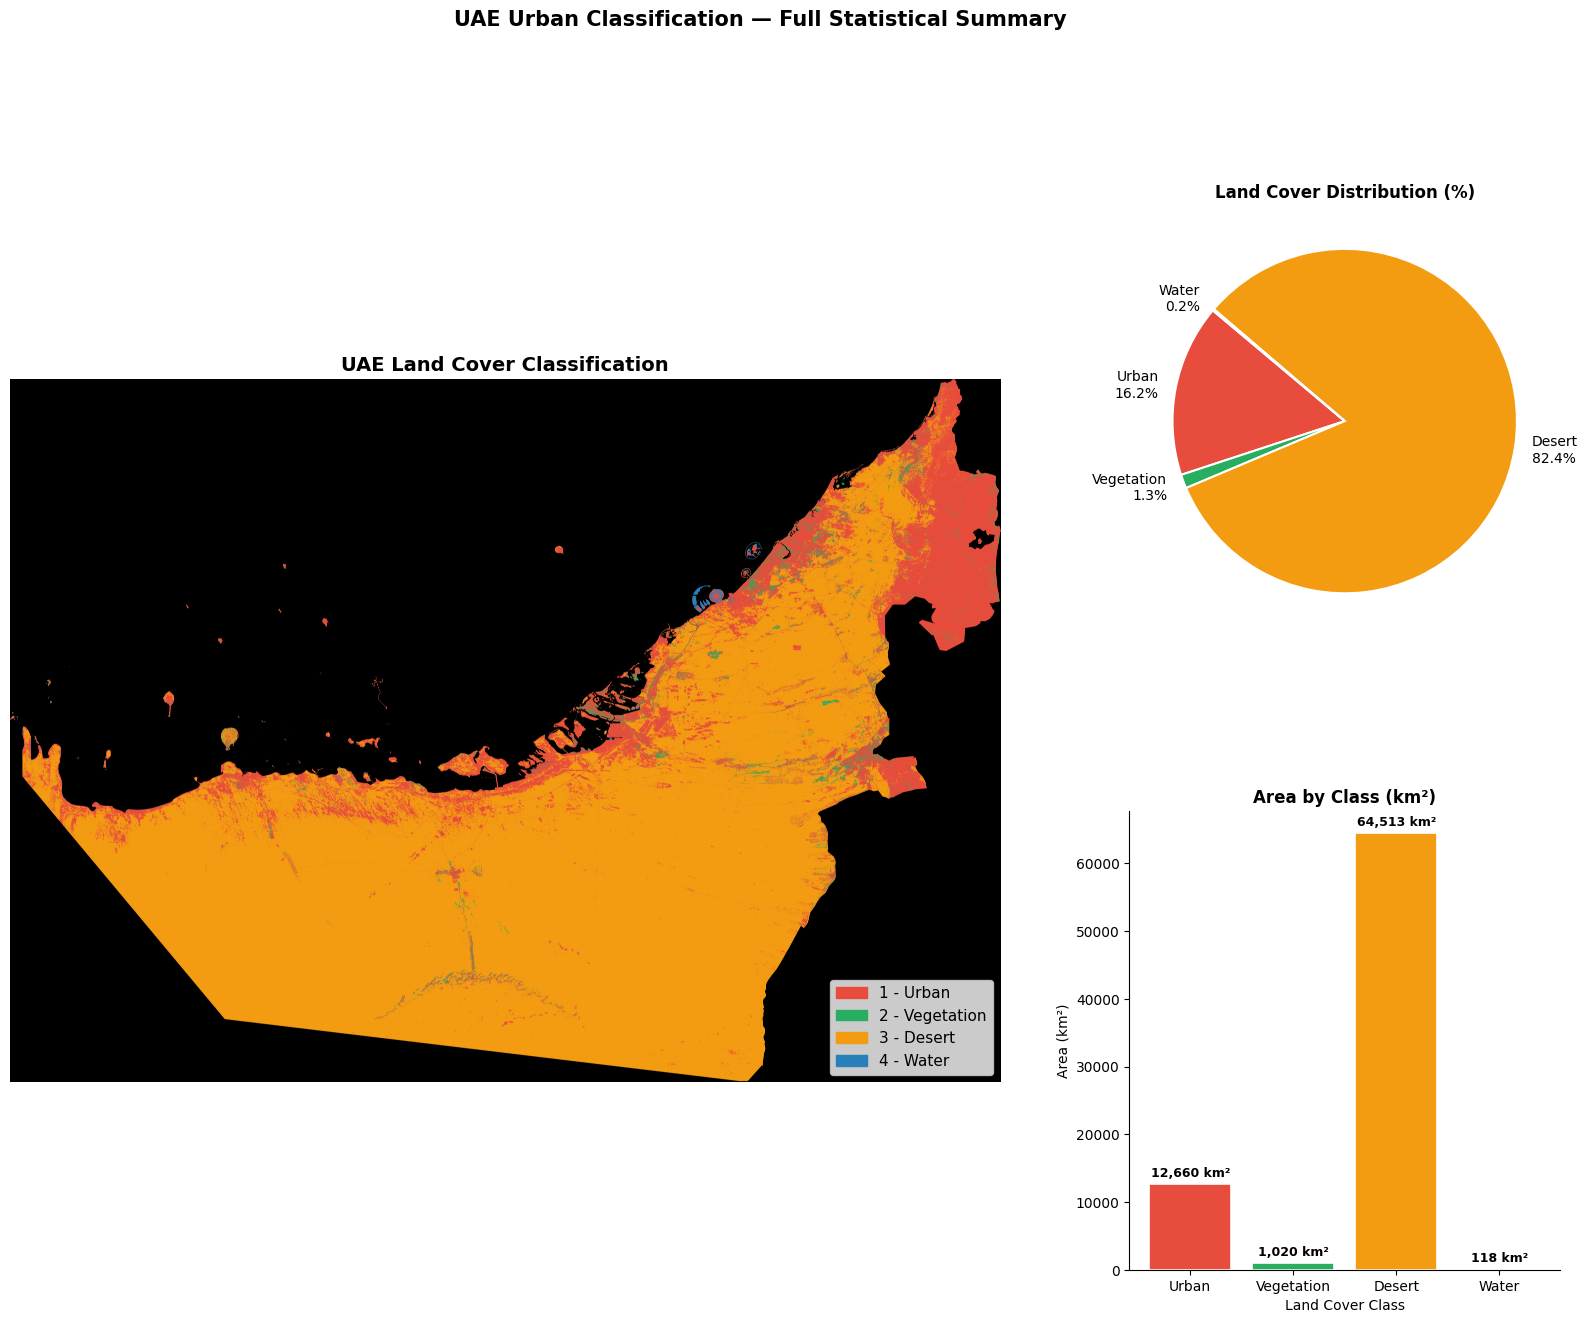

✅ Statistics dashboard saved → /kaggle/working/outputs/07_statistics_dashboard.png

  URBAN ANALYSIS DETAIL
  Urban area              :   12659.88 km²
  Urban area              : 1265987.85 ha
  Urban area              : 12659878519 m²
  Urban % of total area   :      16.2 %
  Urban % of land only    :      16.2 % (excl. water)

  Green cover (Vegetation):    1020.40 km²  (1.3%)
  Water bodies            :     117.70 km²  (0.2%)
  Desert / Bare soil      :   64513.38 km²  (82.4%)

  Total mapped area       :   78311.36 km²


7404

In [2]:
# ============================================================
# CELL 13 — Full Classification Statistics
# ============================================================
import numpy as np
import os
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import gc
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ── Load merged classified map ───────────────────────────────
with rasterio.open('/kaggle/input/datasets/saharfeki/2018-iimage/uae_2018_classified_full.tif') as src:
    full_map  = src.read(1)
    transform = src.transform
    crs       = src.crs
    pixel_res = src.res   # (pixel_width, pixel_height) in CRS units

# ── Pixel area in m² and km² ────────────────────────────────
# If CRS is projected (meters), pixel_res is in meters
# If CRS is geographic (degrees), convert first
if crs.is_geographic:
    # Approximate: 1 degree ≈ 111,320 meters at equator
    pixel_area_m2  = (pixel_res[0] * 111320) * (pixel_res[1] * 111320)
else:
    pixel_area_m2  = pixel_res[0] * pixel_res[1]  # m²

pixel_area_km2 = pixel_area_m2 / 1_000_000  # km²
pixel_area_ha  = pixel_area_m2 / 10_000      # hectares

print(f"Pixel resolution : {pixel_res[0]:.1f} × {pixel_res[1]:.1f} m")
print(f"Pixel area       : {pixel_area_m2:.1f} m²  |  {pixel_area_ha:.4f} ha  |  {pixel_area_km2:.6f} km²")
print(f"CRS              : {crs}")

# ── Class definitions ────────────────────────────────────────
classes = {
    1: ("Urban",      "#e74c3c"),
    2: ("Vegetation", "#27ae60"),
    3: ("Desert",     "#f39c12"),
    4: ("Water",      "#2980b9"),
}

# ── Count pixels per class ───────────────────────────────────
total_pixels = np.sum(full_map > 0)   # valid pixels only
total_area_km2 = total_pixels * pixel_area_km2

stats = {}
for cid, (cname, color) in classes.items():
    n_pixels  = int(np.sum(full_map == cid))
    area_m2   = n_pixels * pixel_area_m2
    area_ha   = n_pixels * pixel_area_ha
    area_km2  = n_pixels * pixel_area_km2
    pct       = 100 * n_pixels / total_pixels if total_pixels > 0 else 0
    stats[cid] = {
        "name"     : cname,
        "color"    : color,
        "pixels"   : n_pixels,
        "area_m2"  : area_m2,
        "area_ha"  : area_ha,
        "area_km2" : area_km2,
        "pct"      : pct,
    }

# ── Print statistics table ───────────────────────────────────
print(f"\n{'='*70}")
print(f"  UAE LAND COVER CLASSIFICATION — STATISTICS")
print(f"{'='*70}")
print(f"  {'Class':<14} {'Pixels':>12} {'Area (km²)':>12} {'Area (ha)':>12} {'%':>8}")
print(f"  {'-'*62}")

for cid, s in stats.items():
    print(f"  {s['name']:<14} {s['pixels']:>12,} "
          f"{s['area_km2']:>12.2f} "
          f"{s['area_ha']:>12.2f} "
          f"{s['pct']:>7.1f}%")

print(f"  {'-'*62}")
print(f"  {'TOTAL':<14} {total_pixels:>12,} "
      f"{total_area_km2:>12.2f} "
      f"{total_area_km2*100:>12.2f} "
      f"{'100.0%':>8}")
print(f"{'='*70}")

# ── Figures ─────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1 — Classified map
ax_map = fig.add_subplot(gs[:, 0:2])
cmap_final = mcolors.ListedColormap([
    "#000000","#e74c3c","#27ae60","#f39c12","#2980b9"
])
ax_map.imshow(full_map, cmap=cmap_final, vmin=0, vmax=4)
legend_patches = [
    mpatches.Patch(color=s["color"], label=f"{cid} - {s['name']}")
    for cid, s in stats.items()
]
ax_map.legend(handles=legend_patches, loc="lower right", fontsize=11)
ax_map.set_title("UAE Land Cover Classification", fontsize=14, fontweight="bold")
ax_map.axis("off")

# 2 — Pie chart (% area)
ax_pie = fig.add_subplot(gs[0, 2])
pie_values = [s["pct"] for s in stats.values()]
pie_colors = [s["color"] for s in stats.values()]
pie_labels = [f"{s['name']}\n{s['pct']:.1f}%" for s in stats.values()]
wedges, texts = ax_pie.pie(
    pie_values,
    colors=pie_colors,
    labels=pie_labels,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in texts:
    text.set_fontsize(10)
ax_pie.set_title("Land Cover Distribution (%)", fontsize=12, fontweight="bold")

# 3 — Bar chart (area in km²)
ax_bar = fig.add_subplot(gs[1, 2])
names  = [s["name"] for s in stats.values()]
areas  = [s["area_km2"] for s in stats.values()]
colors = [s["color"] for s in stats.values()]
bars   = ax_bar.bar(names, areas, color=colors, edgecolor="white", linewidth=1.2)

# Add value labels on bars
for bar, area in zip(bars, areas):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(areas) * 0.01,
        f"{area:,.0f} km²",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax_bar.set_title("Area by Class (km²)", fontsize=12, fontweight="bold")
ax_bar.set_ylabel("Area (km²)")
ax_bar.set_xlabel("Land Cover Class")
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

plt.suptitle("UAE Urban Classification — Full Statistical Summary",
             fontsize=15, fontweight="bold", y=1.01)

plt.savefig(f"{OUTPUT_DIR}/07_statistics_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Statistics dashboard saved → {OUTPUT_DIR}/07_statistics_dashboard.png")

# ── Additional urban-focused metrics ────────────────────────
print(f"\n{'='*70}")
print(f"  URBAN ANALYSIS DETAIL")
print(f"{'='*70}")

urban = stats[1]
total_land_km2 = (stats[1]["area_km2"] + stats[2]["area_km2"] +
                  stats[3]["area_km2"])  # exclude water

print(f"  Urban area              : {urban['area_km2']:>10.2f} km²")
print(f"  Urban area              : {urban['area_ha']:>10.2f} ha")
print(f"  Urban area              : {urban['area_m2']:>10.0f} m²")
print(f"  Urban % of total area   : {urban['pct']:>9.1f} %")
print(f"  Urban % of land only    : "
      f"{100*urban['area_km2']/total_land_km2:>9.1f} % (excl. water)")
print(f"\n  Green cover (Vegetation): {stats[2]['area_km2']:>10.2f} km²  "
      f"({stats[2]['pct']:.1f}%)")
print(f"  Water bodies            : {stats[4]['area_km2']:>10.2f} km²  "
      f"({stats[4]['pct']:.1f}%)")
print(f"  Desert / Bare soil      : {stats[3]['area_km2']:>10.2f} km²  "
      f"({stats[3]['pct']:.1f}%)")
print(f"\n  Total mapped area       : {total_area_km2:>10.2f} km²")
print(f"{'='*70}")

del full_map
gc.collect()

CRS        : EPSG:4326
pixel_res  : (0.0002694945852358565, 0.00026949458523585647)
2024 shape : (13546, 18001)
Geographic CRS detected → using UAE lat correction
Pixel area : 822.20 m²  |  0.0822 ha  |  0.00082220 km²

2018 shape : (12790, 18003)
2018 reprojected shape : (13546, 18001)
✅ Shapes match: (13546, 18001) == (13546, 18001)

  URBAN CHANGE DETECTION 2018 → 2024
  Metric                             Pixels          km²        %
  --------------------------------------------------------------
  Urban Gain (new urban)          3,709,082      3049.60     4.3%
  Urban Loss (urban→other)        1,595,446      1311.77     1.8%
  No Change                      80,652,963     66312.74    93.2%
  --------------------------------------------------------------

  Urban area 2018  : 13,973,744 px  →    11489.19 km²
  Urban area 2024  : 16,087,380 px  →    13227.02 km²
  Net urban change : +2,113,636 px  →    +1737.83 km²
  Urban growth     :      +15.1 %


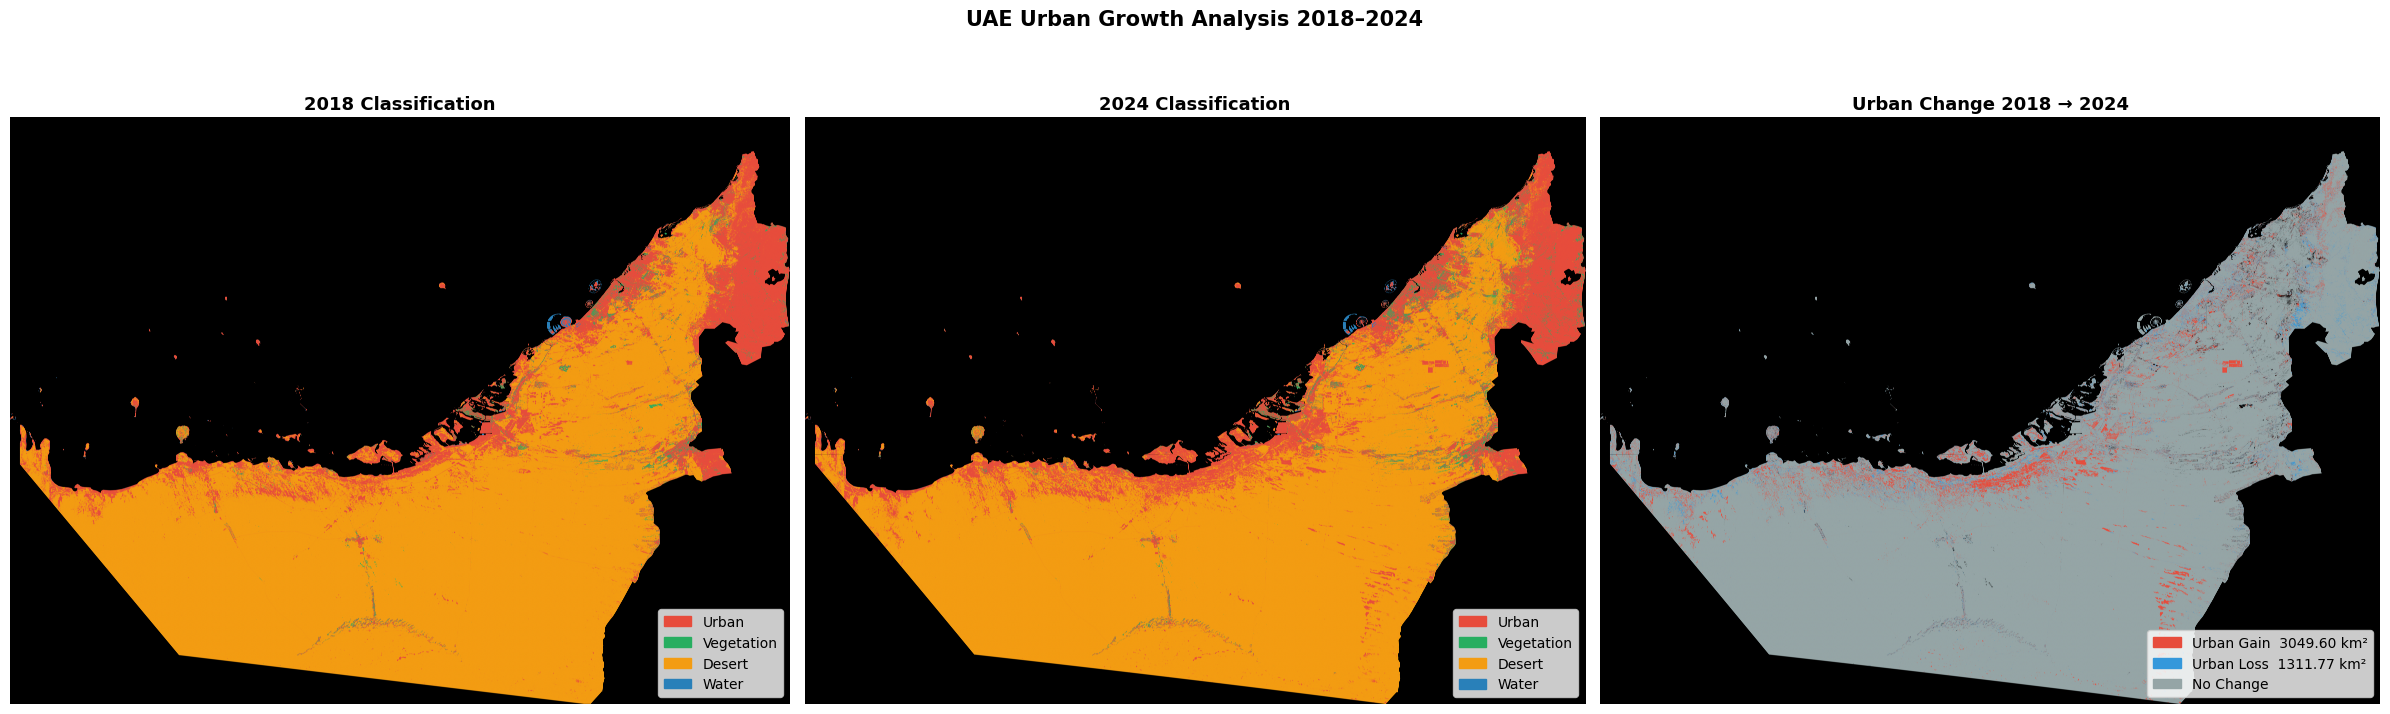


✅ Change map saved → /kaggle/working/outputs/uae_change_2018_2024.tif


0

In [3]:
# ============================================================
# CELL 14 — Change Detection 2018 → 2024 (with alignment fix)
# ============================================================
import numpy as np
import os
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import gc

PATH_2024 = "/kaggle/input/datasets/saharfeki/2024-image/uae_2024_classified_full_clipped.tif"
PATH_2018 = '/kaggle/input/datasets/saharfeki/2018-iimage/uae_2018_classified_full.tif'
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ── Step 1: Load 2024 as reference ──────────────────────────
with rasterio.open(PATH_2024) as src:
    map_2024      = src.read(1)
    profile_ref   = src.profile.copy()
    transform_ref = src.transform
    crs_ref       = src.crs
    h_ref, w_ref  = src.height, src.width
    pixel_res     = src.res

print(f"CRS        : {crs_ref}")
print(f"pixel_res  : {pixel_res}")
print(f"2024 shape : {map_2024.shape}")

# ── Step 2: Compute correct pixel area ──────────────────────
if crs_ref.is_geographic:
    # CRS is in degrees → convert to meters
    # For UAE (latitude ~24°N): 1° lat ≈ 111,320m, 1° lon ≈ 111,320 * cos(24°)
    import math
    lat_center    = 24.0   # approximate center latitude of UAE
    m_per_deg_lat = 111_320
    m_per_deg_lon = 111_320 * math.cos(math.radians(lat_center))
    pixel_area_m2  = (pixel_res[0] * m_per_deg_lon) * (pixel_res[1] * m_per_deg_lat)
    print(f"Geographic CRS detected → using UAE lat correction")
else:
    # CRS is projected (meters) → direct calculation
    pixel_area_m2 = pixel_res[0] * pixel_res[1]
    print(f"Projected CRS detected → direct pixel area")

pixel_area_km2 = pixel_area_m2 / 1_000_000
pixel_area_ha  = pixel_area_m2 / 10_000

print(f"Pixel area : {pixel_area_m2:.2f} m²  |  "
      f"{pixel_area_ha:.4f} ha  |  "
      f"{pixel_area_km2:.8f} km²")

# ── Step 3: Reproject 2018 to match 2024 ────────────────────
with rasterio.open(PATH_2018) as src_2018:
    print(f"\n2018 shape : {src_2018.read(1).shape}")
    map_2018 = np.zeros((h_ref, w_ref), dtype=np.uint8)
    reproject(
        source        = rasterio.band(src_2018, 1),
        destination   = map_2018,
        src_transform = src_2018.transform,
        src_crs       = src_2018.crs,
        dst_transform = transform_ref,
        dst_crs       = crs_ref,
        resampling    = Resampling.nearest
    )

print(f"2018 reprojected shape : {map_2018.shape}")
print(f"✅ Shapes match: {map_2024.shape} == {map_2018.shape}")

# ── Step 4: Valid mask + change detection ────────────────────
valid      = (map_2024 > 0) & (map_2018 > 0)
urban_gain = valid & (map_2018 != 1) & (map_2024 == 1)
urban_loss = valid & (map_2018 == 1) & (map_2024 != 1)
no_change  = valid & (map_2018 == map_2024)

change_map = np.zeros_like(map_2024, dtype=np.uint8)
change_map[no_change]  = 1
change_map[urban_gain] = 2
change_map[urban_loss] = 3

# ── Step 5: Statistics ───────────────────────────────────────
urban_2018_px = int(np.sum((map_2018 == 1) & valid))
urban_2024_px = int(np.sum((map_2024 == 1) & valid))
gain_px       = int(np.sum(urban_gain))
loss_px       = int(np.sum(urban_loss))
total_valid   = int(np.sum(valid))
growth_pct    = 100 * (urban_2024_px - urban_2018_px) / urban_2018_px \
                if urban_2018_px > 0 else 0

print(f"\n{'='*65}")
print(f"  URBAN CHANGE DETECTION 2018 → 2024")
print(f"{'='*65}")
print(f"  {'Metric':<30} {'Pixels':>10} {'km²':>12} {'%':>8}")
print(f"  {'-'*62}")

for label, px in [
    ("Urban Gain (new urban)",    gain_px),
    ("Urban Loss (urban→other)",  loss_px),
    ("No Change",                 int(np.sum(no_change))),
]:
    km2 = px * pixel_area_km2
    pct = 100 * px / total_valid if total_valid > 0 else 0
    print(f"  {label:<30} {px:>10,} {km2:>12.2f} {pct:>7.1f}%")

print(f"  {'-'*62}")
print(f"\n  Urban area 2018  : {urban_2018_px:>10,} px  →  "
      f"{urban_2018_px * pixel_area_km2:>10.2f} km²")
print(f"  Urban area 2024  : {urban_2024_px:>10,} px  →  "
      f"{urban_2024_px * pixel_area_km2:>10.2f} km²")
print(f"  Net urban change : {urban_2024_px - urban_2018_px:>+10,} px  →  "
      f"{(urban_2024_px - urban_2018_px) * pixel_area_km2:>+10.2f} km²")
print(f"  Urban growth     : {growth_pct:>+10.1f} %")
print(f"{'='*65}")

# ── Step 6: Visualize ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

cmap_cls = mcolors.ListedColormap(
    ["#000000","#e74c3c","#27ae60","#f39c12","#2980b9"]
)
cmap_chg = mcolors.ListedColormap(
    ["#000000","#95a5a6","#e74c3c","#3498db"]
)
legend_cls = [
    mpatches.Patch(color="#e74c3c", label="Urban"),
    mpatches.Patch(color="#27ae60", label="Vegetation"),
    mpatches.Patch(color="#f39c12", label="Desert"),
    mpatches.Patch(color="#2980b9", label="Water"),
]

axes[0].imshow(map_2018, cmap=cmap_cls, vmin=0, vmax=4)
axes[0].legend(handles=legend_cls, loc="lower right", fontsize=10)
axes[0].set_title("2018 Classification", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(map_2024, cmap=cmap_cls, vmin=0, vmax=4)
axes[1].legend(handles=legend_cls, loc="lower right", fontsize=10)
axes[1].set_title("2024 Classification", fontsize=13, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(change_map, cmap=cmap_chg, vmin=0, vmax=3)
legend_chg = [
    mpatches.Patch(color="#e74c3c",
                   label=f"Urban Gain  "
                         f"{gain_px * pixel_area_km2:.2f} km²"),
    mpatches.Patch(color="#3498db",
                   label=f"Urban Loss  "
                         f"{loss_px * pixel_area_km2:.2f} km²"),
    mpatches.Patch(color="#95a5a6", label="No Change"),
]
axes[2].legend(handles=legend_chg, loc="lower right", fontsize=10)
axes[2].set_title("Urban Change 2018 → 2024", fontsize=13, fontweight="bold")
axes[2].axis("off")

plt.suptitle("UAE Urban Growth Analysis 2018–2024",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_change_detection_2018_2024.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Step 7: Save change GeoTIFF ─────────────────────────────
profile_ref.update(count=1, dtype=np.uint8, nodata=0)
change_path = f"{OUTPUT_DIR}/uae_change_2018_2024.tif"
with rasterio.open(change_path, "w", **profile_ref) as dst:
    dst.write(change_map, 1)

print(f"\n✅ Change map saved → {change_path}")

del map_2018, map_2024, change_map
del urban_gain, urban_loss, no_change, valid
gc.collect()

Pixel resolution : 0.0 × 0.0 m
Pixel area       : 900.0 m²  |  0.0900 ha  |  0.000900 km²
CRS              : EPSG:4326

  UAE LAND COVER CLASSIFICATION — STATISTICS
  Class                Pixels   Area (km²)    Area (ha)        %
  --------------------------------------------------------------
  Urban            14,734,085     13260.80   1326079.78    16.9%
  Vegetation        1,153,988      1038.60    103859.87     1.3%
  Desert           71,067,178     63961.05   6396104.53    81.7%
  Water                56,571        50.91      5091.44     0.1%
  --------------------------------------------------------------
  TOTAL            87,011,822     78311.36   7831135.62   100.0%


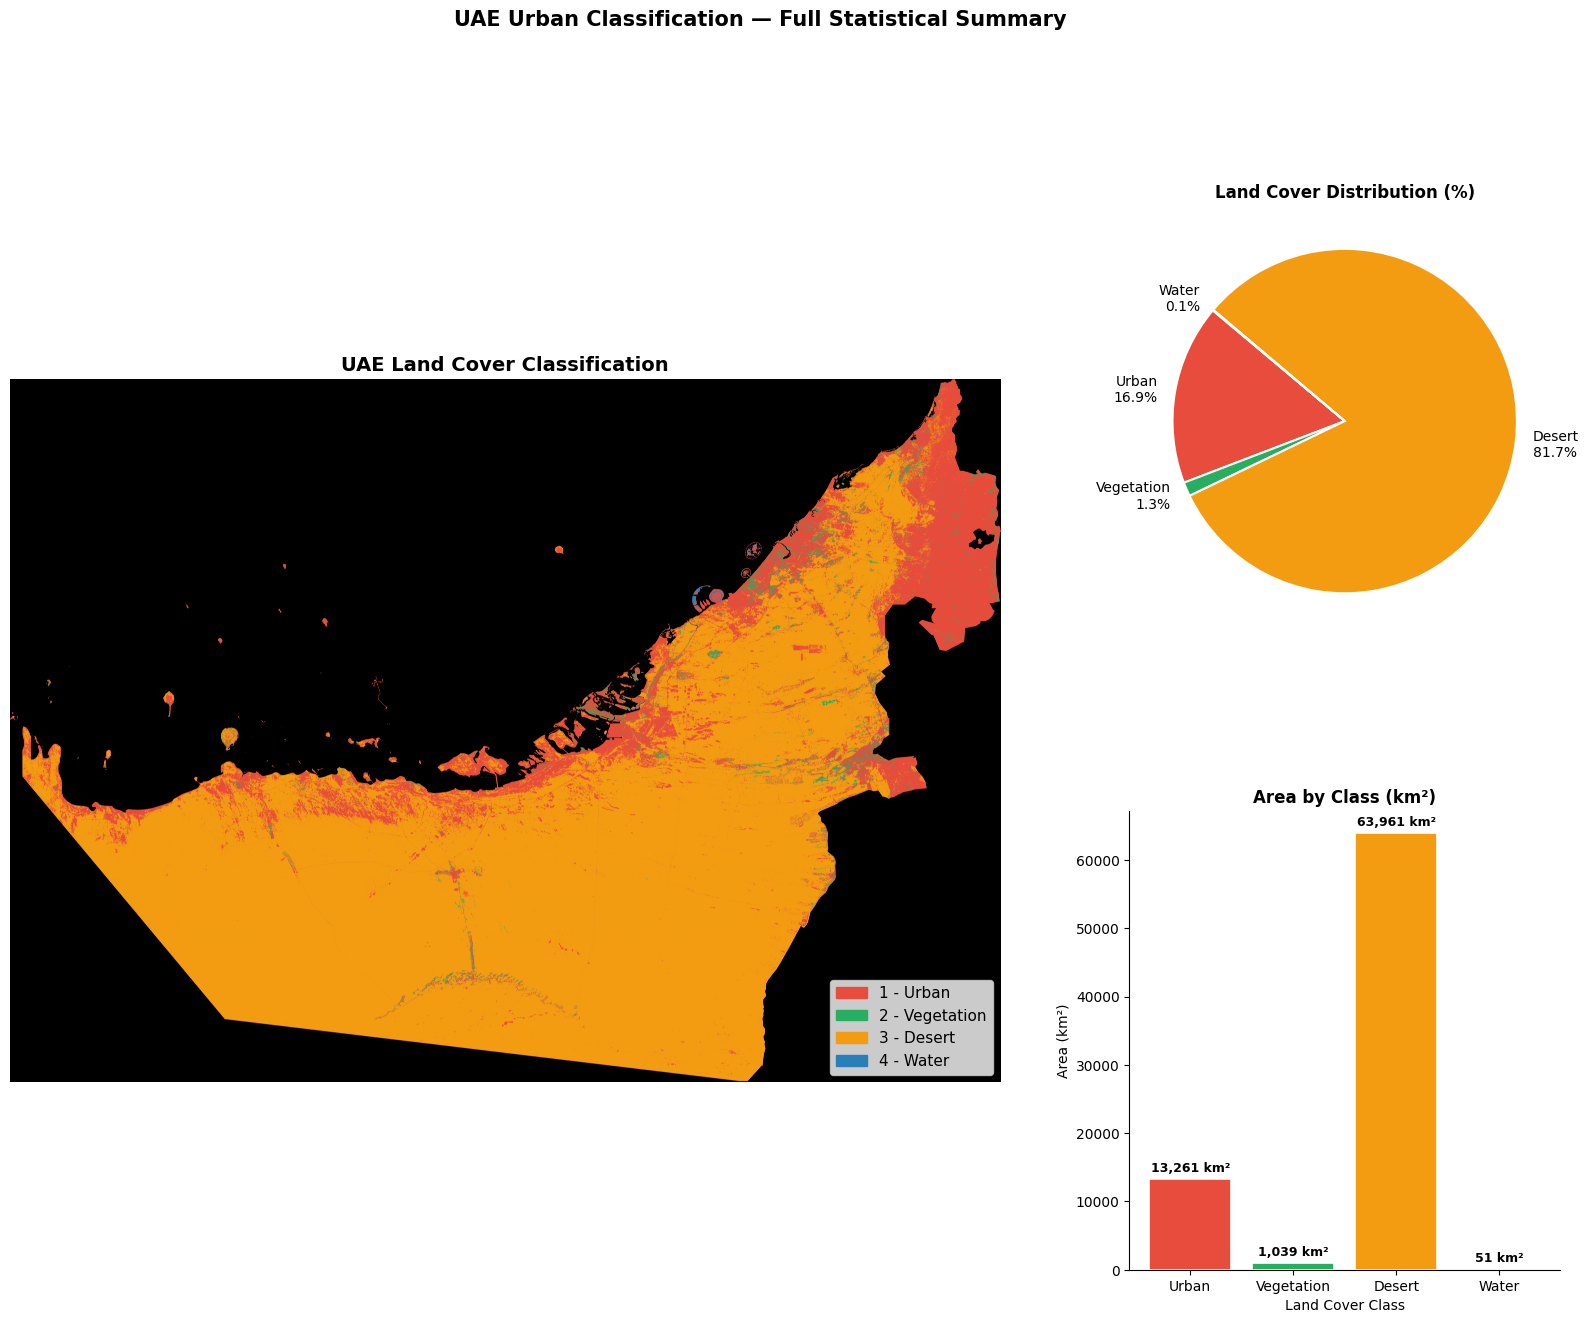

✅ Statistics dashboard saved → /kaggle/working/outputs/07_statistics_dashboard.png

  URBAN ANALYSIS DETAIL
  Urban area              :   13260.80 km²
  Urban area              : 1326079.78 ha
  Urban area              : 13260797816 m²
  Urban % of total area   :      16.9 %
  Urban % of land only    :      16.9 % (excl. water)

  Green cover (Vegetation):    1038.60 km²  (1.3%)
  Water bodies            :      50.91 km²  (0.1%)
  Desert / Bare soil      :   63961.05 km²  (81.7%)

  Total mapped area       :   78311.36 km²


7374

In [4]:
# ============================================================
# CELL 13 — Full Classification Statistics
# ============================================================
import numpy as np
import os
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import gc
OUTPUT_DIR = "/kaggle/working/outputs"

# ── Load merged classified map ───────────────────────────────
with rasterio.open('/kaggle/input/datasets/saharfeki/2021-image/uae_2021_classified_full.tif') as src:
    full_map  = src.read(1)
    transform = src.transform
    crs       = src.crs
    pixel_res = src.res   # (pixel_width, pixel_height) in CRS units

# ── Pixel area in m² and km² ────────────────────────────────
# If CRS is projected (meters), pixel_res is in meters
# If CRS is geographic (degrees), convert first
if crs.is_geographic:
    # Approximate: 1 degree ≈ 111,320 meters at equator
    pixel_area_m2  = (pixel_res[0] * 111320) * (pixel_res[1] * 111320)
else:
    pixel_area_m2  = pixel_res[0] * pixel_res[1]  # m²

pixel_area_km2 = pixel_area_m2 / 1_000_000  # km²
pixel_area_ha  = pixel_area_m2 / 10_000      # hectares

print(f"Pixel resolution : {pixel_res[0]:.1f} × {pixel_res[1]:.1f} m")
print(f"Pixel area       : {pixel_area_m2:.1f} m²  |  {pixel_area_ha:.4f} ha  |  {pixel_area_km2:.6f} km²")
print(f"CRS              : {crs}")

# ── Class definitions ────────────────────────────────────────
classes = {
    1: ("Urban",      "#e74c3c"),
    2: ("Vegetation", "#27ae60"),
    3: ("Desert",     "#f39c12"),
    4: ("Water",      "#2980b9"),
}

# ── Count pixels per class ───────────────────────────────────
total_pixels = np.sum(full_map > 0)   # valid pixels only
total_area_km2 = total_pixels * pixel_area_km2

stats = {}
for cid, (cname, color) in classes.items():
    n_pixels  = int(np.sum(full_map == cid))
    area_m2   = n_pixels * pixel_area_m2
    area_ha   = n_pixels * pixel_area_ha
    area_km2  = n_pixels * pixel_area_km2
    pct       = 100 * n_pixels / total_pixels if total_pixels > 0 else 0
    stats[cid] = {
        "name"     : cname,
        "color"    : color,
        "pixels"   : n_pixels,
        "area_m2"  : area_m2,
        "area_ha"  : area_ha,
        "area_km2" : area_km2,
        "pct"      : pct,
    }

# ── Print statistics table ───────────────────────────────────
print(f"\n{'='*70}")
print(f"  UAE LAND COVER CLASSIFICATION — STATISTICS")
print(f"{'='*70}")
print(f"  {'Class':<14} {'Pixels':>12} {'Area (km²)':>12} {'Area (ha)':>12} {'%':>8}")
print(f"  {'-'*62}")

for cid, s in stats.items():
    print(f"  {s['name']:<14} {s['pixels']:>12,} "
          f"{s['area_km2']:>12.2f} "
          f"{s['area_ha']:>12.2f} "
          f"{s['pct']:>7.1f}%")

print(f"  {'-'*62}")
print(f"  {'TOTAL':<14} {total_pixels:>12,} "
      f"{total_area_km2:>12.2f} "
      f"{total_area_km2*100:>12.2f} "
      f"{'100.0%':>8}")
print(f"{'='*70}")

# ── Figures ─────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs  = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1 — Classified map
ax_map = fig.add_subplot(gs[:, 0:2])
cmap_final = mcolors.ListedColormap([
    "#000000","#e74c3c","#27ae60","#f39c12","#2980b9"
])
ax_map.imshow(full_map, cmap=cmap_final, vmin=0, vmax=4)
legend_patches = [
    mpatches.Patch(color=s["color"], label=f"{cid} - {s['name']}")
    for cid, s in stats.items()
]
ax_map.legend(handles=legend_patches, loc="lower right", fontsize=11)
ax_map.set_title("UAE Land Cover Classification", fontsize=14, fontweight="bold")
ax_map.axis("off")

# 2 — Pie chart (% area)
ax_pie = fig.add_subplot(gs[0, 2])
pie_values = [s["pct"] for s in stats.values()]
pie_colors = [s["color"] for s in stats.values()]
pie_labels = [f"{s['name']}\n{s['pct']:.1f}%" for s in stats.values()]
wedges, texts = ax_pie.pie(
    pie_values,
    colors=pie_colors,
    labels=pie_labels,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
for text in texts:
    text.set_fontsize(10)
ax_pie.set_title("Land Cover Distribution (%)", fontsize=12, fontweight="bold")

# 3 — Bar chart (area in km²)
ax_bar = fig.add_subplot(gs[1, 2])
names  = [s["name"] for s in stats.values()]
areas  = [s["area_km2"] for s in stats.values()]
colors = [s["color"] for s in stats.values()]
bars   = ax_bar.bar(names, areas, color=colors, edgecolor="white", linewidth=1.2)

# Add value labels on bars
for bar, area in zip(bars, areas):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(areas) * 0.01,
        f"{area:,.0f} km²",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

ax_bar.set_title("Area by Class (km²)", fontsize=12, fontweight="bold")
ax_bar.set_ylabel("Area (km²)")
ax_bar.set_xlabel("Land Cover Class")
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

plt.suptitle("UAE Urban Classification — Full Statistical Summary",
             fontsize=15, fontweight="bold", y=1.01)

plt.savefig(f"{OUTPUT_DIR}/07_statistics_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Statistics dashboard saved → {OUTPUT_DIR}/07_statistics_dashboard.png")

# ── Additional urban-focused metrics ────────────────────────
print(f"\n{'='*70}")
print(f"  URBAN ANALYSIS DETAIL")
print(f"{'='*70}")

urban = stats[1]
total_land_km2 = (stats[1]["area_km2"] + stats[2]["area_km2"] +
                  stats[3]["area_km2"])  # exclude water

print(f"  Urban area              : {urban['area_km2']:>10.2f} km²")
print(f"  Urban area              : {urban['area_ha']:>10.2f} ha")
print(f"  Urban area              : {urban['area_m2']:>10.0f} m²")
print(f"  Urban % of total area   : {urban['pct']:>9.1f} %")
print(f"  Urban % of land only    : "
      f"{100*urban['area_km2']/total_land_km2:>9.1f} % (excl. water)")
print(f"\n  Green cover (Vegetation): {stats[2]['area_km2']:>10.2f} km²  "
      f"({stats[2]['pct']:.1f}%)")
print(f"  Water bodies            : {stats[4]['area_km2']:>10.2f} km²  "
      f"({stats[4]['pct']:.1f}%)")
print(f"  Desert / Bare soil      : {stats[3]['area_km2']:>10.2f} km²  "
      f"({stats[3]['pct']:.1f}%)")
print(f"\n  Total mapped area       : {total_area_km2:>10.2f} km²")
print(f"{'='*70}")

del full_map
gc.collect()

CRS        : EPSG:4326
pixel_res  : (0.00026949458523585647, 0.00026949458523585647)
2024 shape : (12790, 18003)
Geographic CRS detected → using UAE lat correction
Pixel area : 822.20 m²  |  0.0822 ha  |  0.00082220 km²

2018 shape : (12790, 18003)
2018 reprojected shape : (12790, 18003)
✅ Shapes match: (12790, 18003) == (12790, 18003)

  URBAN CHANGE DETECTION 2018 → 2021
  Metric                             Pixels          km²        %
  --------------------------------------------------------------
  Urban Gain (new urban)          1,800,389      1480.28     2.1%
  Urban Loss (urban→other)        1,132,707       931.31     1.3%
  No Change                      83,869,344     68957.24    96.4%
  --------------------------------------------------------------

  Urban area 2018  : 14,066,403 px  →    11565.37 km²
  Urban area 2021  : 14,734,085 px  →    12114.34 km²
  Net urban change :   +667,682 px  →     +548.97 km²
  Urban growth     :       +4.7 %


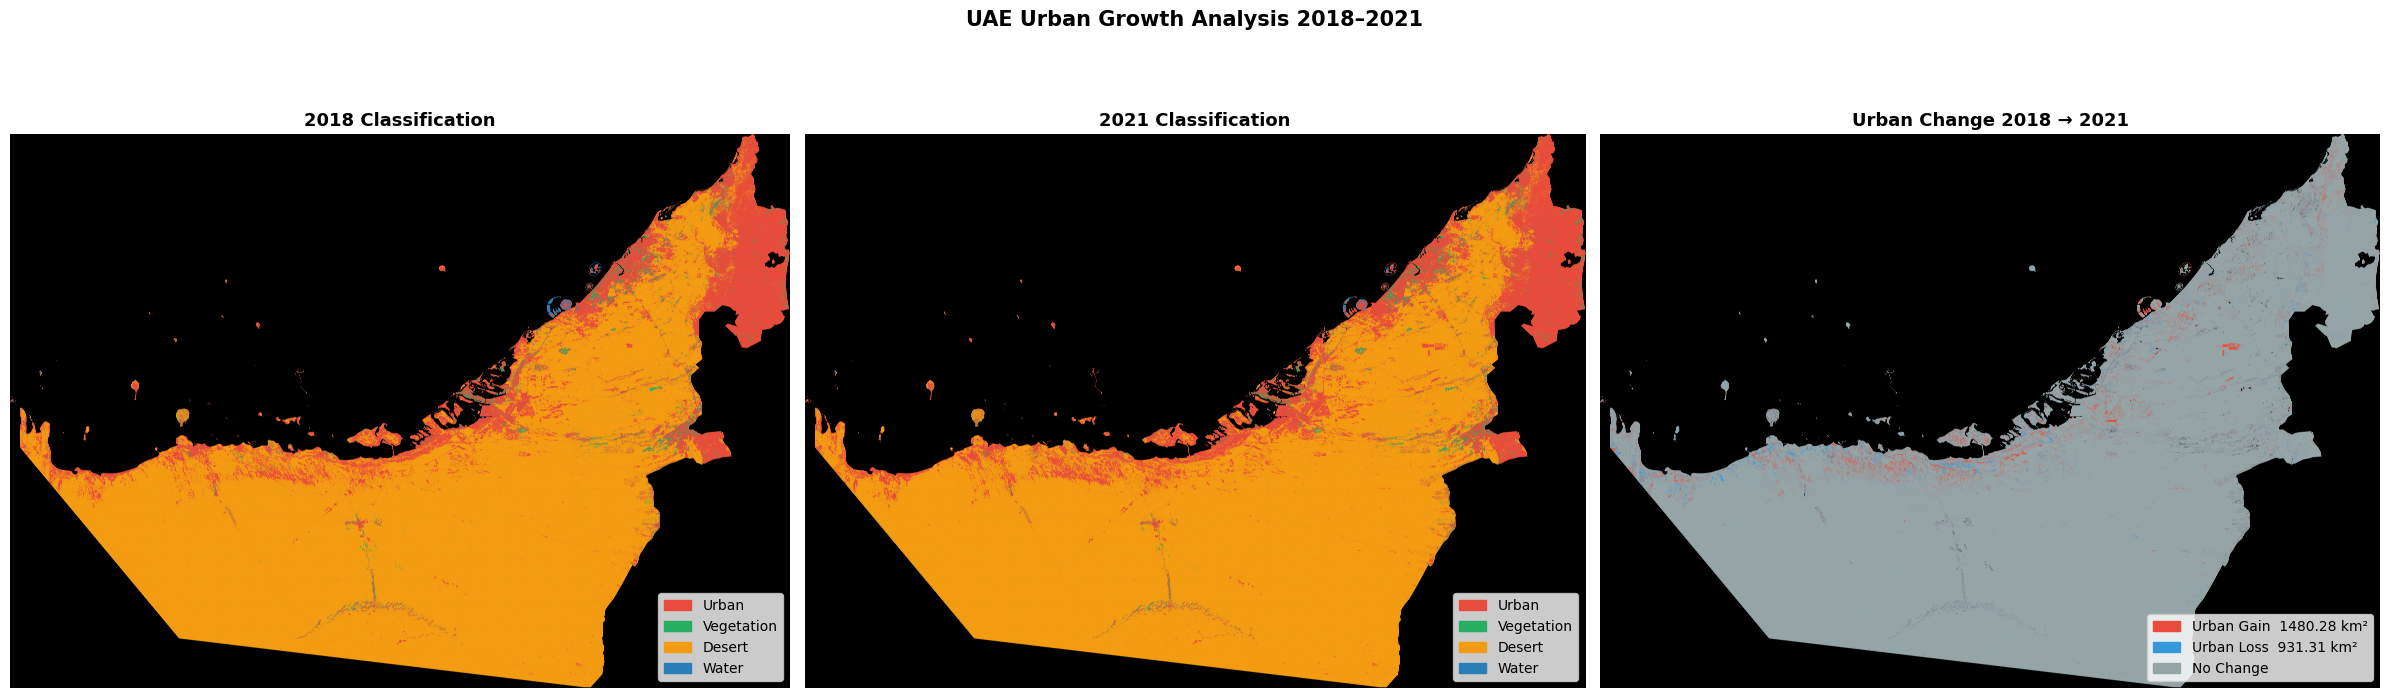


✅ Change map saved → /kaggle/working/outputs/uae_change_2018_2024.tif


7992

In [5]:
# ============================================================
# CELL 14 — Change Detection 2018 → 2024 (with alignment fix)
# ============================================================
import numpy as np
import os
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import gc

PATH_2024 = "/kaggle/input/datasets/saharfeki/2021-image/uae_2021_classified_full.tif"
PATH_2018 = '/kaggle/input/datasets/saharfeki/2018-iimage/uae_2018_classified_full.tif'
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ── Step 1: Load 2024 as reference ──────────────────────────
with rasterio.open(PATH_2024) as src:
    map_2024      = src.read(1)
    profile_ref   = src.profile.copy()
    transform_ref = src.transform
    crs_ref       = src.crs
    h_ref, w_ref  = src.height, src.width
    pixel_res     = src.res

print(f"CRS        : {crs_ref}")
print(f"pixel_res  : {pixel_res}")
print(f"2024 shape : {map_2024.shape}")

# ── Step 2: Compute correct pixel area ──────────────────────
if crs_ref.is_geographic:
    # CRS is in degrees → convert to meters
    # For UAE (latitude ~24°N): 1° lat ≈ 111,320m, 1° lon ≈ 111,320 * cos(24°)
    import math
    lat_center    = 24.0   # approximate center latitude of UAE
    m_per_deg_lat = 111_320
    m_per_deg_lon = 111_320 * math.cos(math.radians(lat_center))
    pixel_area_m2  = (pixel_res[0] * m_per_deg_lon) * (pixel_res[1] * m_per_deg_lat)
    print(f"Geographic CRS detected → using UAE lat correction")
else:
    # CRS is projected (meters) → direct calculation
    pixel_area_m2 = pixel_res[0] * pixel_res[1]
    print(f"Projected CRS detected → direct pixel area")

pixel_area_km2 = pixel_area_m2 / 1_000_000
pixel_area_ha  = pixel_area_m2 / 10_000

print(f"Pixel area : {pixel_area_m2:.2f} m²  |  "
      f"{pixel_area_ha:.4f} ha  |  "
      f"{pixel_area_km2:.8f} km²")

# ── Step 3: Reproject 2018 to match 2024 ────────────────────
with rasterio.open(PATH_2018) as src_2018:
    print(f"\n2018 shape : {src_2018.read(1).shape}")
    map_2018 = np.zeros((h_ref, w_ref), dtype=np.uint8)
    reproject(
        source        = rasterio.band(src_2018, 1),
        destination   = map_2018,
        src_transform = src_2018.transform,
        src_crs       = src_2018.crs,
        dst_transform = transform_ref,
        dst_crs       = crs_ref,
        resampling    = Resampling.nearest
    )

print(f"2018 reprojected shape : {map_2018.shape}")
print(f"✅ Shapes match: {map_2024.shape} == {map_2018.shape}")

# ── Step 4: Valid mask + change detection ────────────────────
valid      = (map_2024 > 0) & (map_2018 > 0)
urban_gain = valid & (map_2018 != 1) & (map_2024 == 1)
urban_loss = valid & (map_2018 == 1) & (map_2024 != 1)
no_change  = valid & (map_2018 == map_2024)

change_map = np.zeros_like(map_2024, dtype=np.uint8)
change_map[no_change]  = 1
change_map[urban_gain] = 2
change_map[urban_loss] = 3

# ── Step 5: Statistics ───────────────────────────────────────
urban_2018_px = int(np.sum((map_2018 == 1) & valid))
urban_2024_px = int(np.sum((map_2024 == 1) & valid))
gain_px       = int(np.sum(urban_gain))
loss_px       = int(np.sum(urban_loss))
total_valid   = int(np.sum(valid))
growth_pct    = 100 * (urban_2024_px - urban_2018_px) / urban_2018_px \
                if urban_2018_px > 0 else 0

print(f"\n{'='*65}")
print(f"  URBAN CHANGE DETECTION 2018 → 2021")
print(f"{'='*65}")
print(f"  {'Metric':<30} {'Pixels':>10} {'km²':>12} {'%':>8}")
print(f"  {'-'*62}")

for label, px in [
    ("Urban Gain (new urban)",    gain_px),
    ("Urban Loss (urban→other)",  loss_px),
    ("No Change",                 int(np.sum(no_change))),
]:
    km2 = px * pixel_area_km2
    pct = 100 * px / total_valid if total_valid > 0 else 0
    print(f"  {label:<30} {px:>10,} {km2:>12.2f} {pct:>7.1f}%")

print(f"  {'-'*62}")
print(f"\n  Urban area 2018  : {urban_2018_px:>10,} px  →  "
      f"{urban_2018_px * pixel_area_km2:>10.2f} km²")
print(f"  Urban area 2021  : {urban_2024_px:>10,} px  →  "
      f"{urban_2024_px * pixel_area_km2:>10.2f} km²")
print(f"  Net urban change : {urban_2024_px - urban_2018_px:>+10,} px  →  "
      f"{(urban_2024_px - urban_2018_px) * pixel_area_km2:>+10.2f} km²")
print(f"  Urban growth     : {growth_pct:>+10.1f} %")
print(f"{'='*65}")

# ── Step 6: Visualize ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

cmap_cls = mcolors.ListedColormap(
    ["#000000","#e74c3c","#27ae60","#f39c12","#2980b9"]
)
cmap_chg = mcolors.ListedColormap(
    ["#000000","#95a5a6","#e74c3c","#3498db"]
)
legend_cls = [
    mpatches.Patch(color="#e74c3c", label="Urban"),
    mpatches.Patch(color="#27ae60", label="Vegetation"),
    mpatches.Patch(color="#f39c12", label="Desert"),
    mpatches.Patch(color="#2980b9", label="Water"),
]

axes[0].imshow(map_2018, cmap=cmap_cls, vmin=0, vmax=4)
axes[0].legend(handles=legend_cls, loc="lower right", fontsize=10)
axes[0].set_title("2018 Classification", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(map_2024, cmap=cmap_cls, vmin=0, vmax=4)
axes[1].legend(handles=legend_cls, loc="lower right", fontsize=10)
axes[1].set_title("2021 Classification", fontsize=13, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(change_map, cmap=cmap_chg, vmin=0, vmax=3)
legend_chg = [
    mpatches.Patch(color="#e74c3c",
                   label=f"Urban Gain  "
                         f"{gain_px * pixel_area_km2:.2f} km²"),
    mpatches.Patch(color="#3498db",
                   label=f"Urban Loss  "
                         f"{loss_px * pixel_area_km2:.2f} km²"),
    mpatches.Patch(color="#95a5a6", label="No Change"),
]
axes[2].legend(handles=legend_chg, loc="lower right", fontsize=10)
axes[2].set_title("Urban Change 2018 → 2021", fontsize=13, fontweight="bold")
axes[2].axis("off")

plt.suptitle("UAE Urban Growth Analysis 2018–2021",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_change_detection_2018_2024.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Step 7: Save change GeoTIFF ─────────────────────────────
profile_ref.update(count=1, dtype=np.uint8, nodata=0)
change_path = f"{OUTPUT_DIR}/uae_change_2018_2024.tif"
with rasterio.open(change_path, "w", **profile_ref) as dst:
    dst.write(change_map, 1)

print(f"\n✅ Change map saved → {change_path}")

del map_2018, map_2024, change_map
del urban_gain, urban_loss, no_change, valid
gc.collect()

CRS        : EPSG:4326
pixel_res  : (0.0002694945852358565, 0.00026949458523585647)
2024 shape : (13546, 18001)
Geographic CRS detected → using UAE lat correction
Pixel area : 822.20 m²  |  0.0822 ha  |  0.00082220 km²

2018 shape : (12790, 18003)
2021 reprojected shape : (13546, 18001)
✅ Shapes match: (13546, 18001) == (13546, 18001)

  URBAN CHANGE DETECTION 2021 → 2024
  Metric                             Pixels          km²        %
  --------------------------------------------------------------
  Urban Gain (new urban)          3,124,267      2568.77     3.6%
  Urban Loss (urban→other)        1,665,346      1369.24     1.9%
  No Change                      81,241,714     66796.81    93.9%
  --------------------------------------------------------------

  Urban area 2021  : 14,628,459 px  →    12027.50 km²
  Urban area 2024  : 16,087,380 px  →    13227.02 km²
  Net urban change : +1,458,921 px  →    +1199.52 km²
  Urban growth     :      +10.0 %


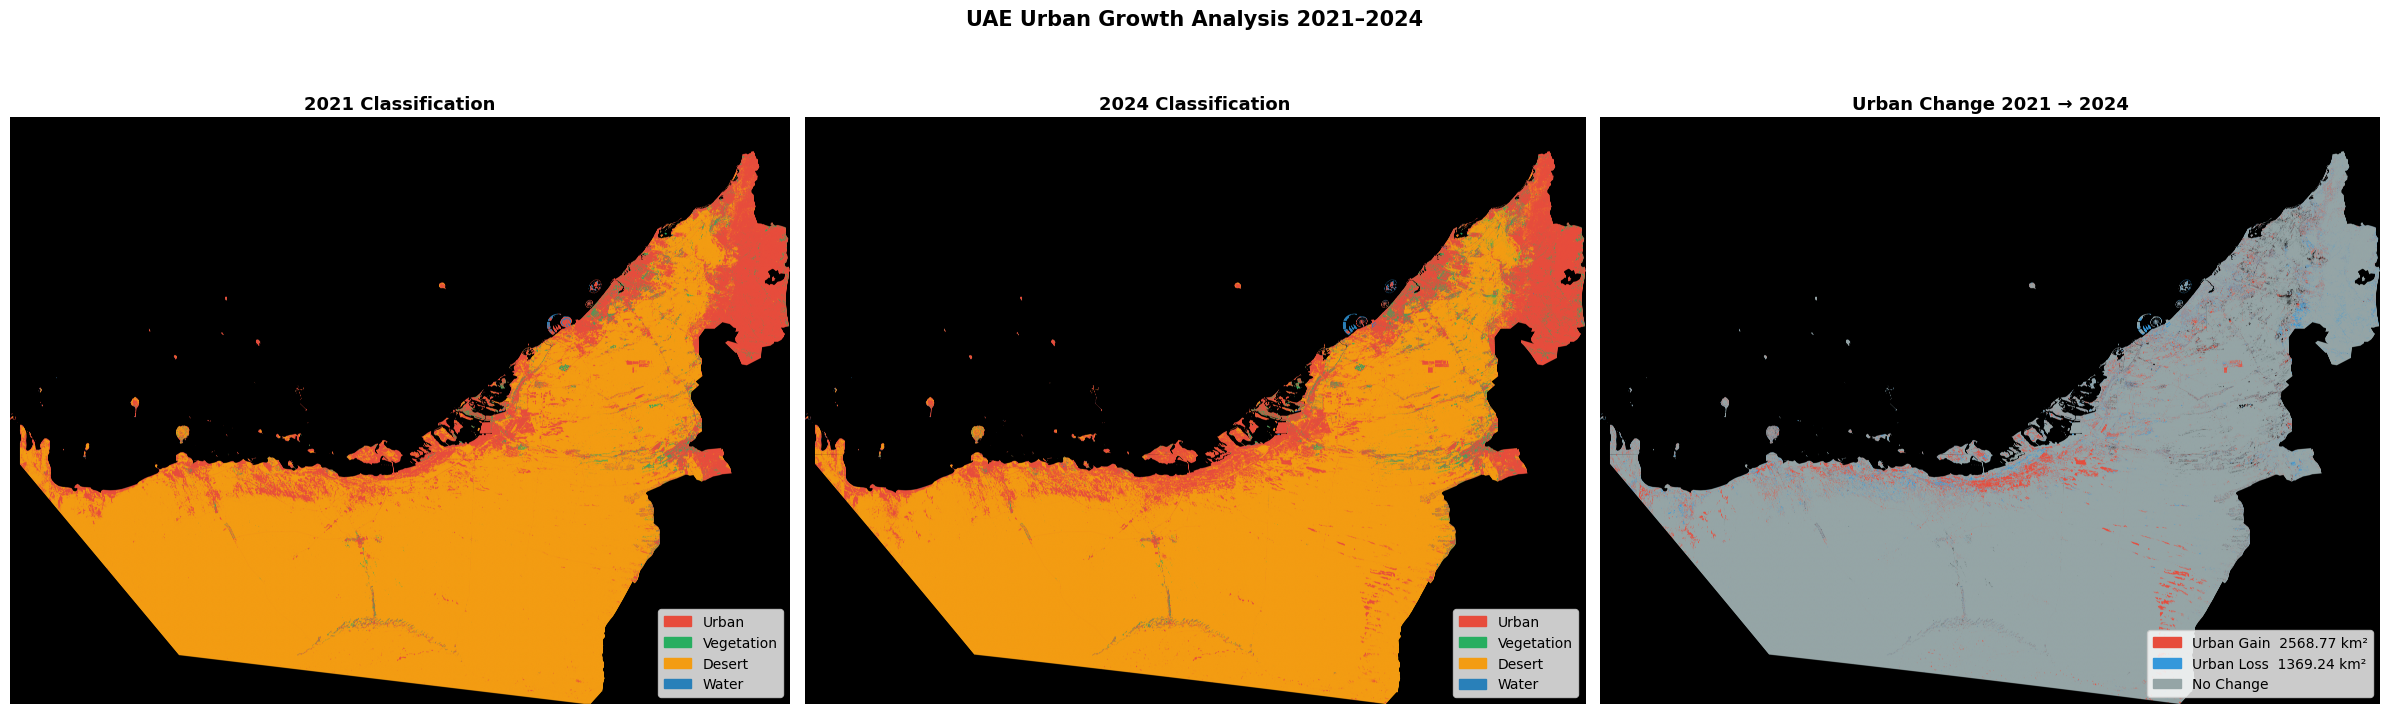


✅ Change map saved → /kaggle/working/outputs/uae_change_2021_2024.tif


7997

In [6]:
# ============================================================
# CELL 14 — Change Detection 2018 → 2024 (with alignment fix)
# ============================================================
import numpy as np
import os
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import gc

PATH_2024 = "/kaggle/input/datasets/saharfeki/2024-image/uae_2024_classified_full_clipped.tif"
PATH_2018 = '/kaggle/input/datasets/saharfeki/2021-image/uae_2021_classified_full.tif'
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
# ── Step 1: Load 2024 as reference ──────────────────────────
with rasterio.open(PATH_2024) as src:
    map_2024      = src.read(1)
    profile_ref   = src.profile.copy()
    transform_ref = src.transform
    crs_ref       = src.crs
    h_ref, w_ref  = src.height, src.width
    pixel_res     = src.res

print(f"CRS        : {crs_ref}")
print(f"pixel_res  : {pixel_res}")
print(f"2024 shape : {map_2024.shape}")

# ── Step 2: Compute correct pixel area ──────────────────────
if crs_ref.is_geographic:
    # CRS is in degrees → convert to meters
    # For UAE (latitude ~24°N): 1° lat ≈ 111,320m, 1° lon ≈ 111,320 * cos(24°)
    import math
    lat_center    = 24.0   # approximate center latitude of UAE
    m_per_deg_lat = 111_320
    m_per_deg_lon = 111_320 * math.cos(math.radians(lat_center))
    pixel_area_m2  = (pixel_res[0] * m_per_deg_lon) * (pixel_res[1] * m_per_deg_lat)
    print(f"Geographic CRS detected → using UAE lat correction")
else:
    # CRS is projected (meters) → direct calculation
    pixel_area_m2 = pixel_res[0] * pixel_res[1]
    print(f"Projected CRS detected → direct pixel area")

pixel_area_km2 = pixel_area_m2 / 1_000_000
pixel_area_ha  = pixel_area_m2 / 10_000

print(f"Pixel area : {pixel_area_m2:.2f} m²  |  "
      f"{pixel_area_ha:.4f} ha  |  "
      f"{pixel_area_km2:.8f} km²")

# ── Step 3: Reproject 2018 to match 2024 ────────────────────
with rasterio.open(PATH_2018) as src_2018:
    print(f"\n2018 shape : {src_2018.read(1).shape}")
    map_2018 = np.zeros((h_ref, w_ref), dtype=np.uint8)
    reproject(
        source        = rasterio.band(src_2018, 1),
        destination   = map_2018,
        src_transform = src_2018.transform,
        src_crs       = src_2018.crs,
        dst_transform = transform_ref,
        dst_crs       = crs_ref,
        resampling    = Resampling.nearest
    )

print(f"2021 reprojected shape : {map_2018.shape}")
print(f"✅ Shapes match: {map_2024.shape} == {map_2018.shape}")

# ── Step 4: Valid mask + change detection ────────────────────
valid      = (map_2024 > 0) & (map_2018 > 0)
urban_gain = valid & (map_2018 != 1) & (map_2024 == 1)
urban_loss = valid & (map_2018 == 1) & (map_2024 != 1)
no_change  = valid & (map_2018 == map_2024)

change_map = np.zeros_like(map_2024, dtype=np.uint8)
change_map[no_change]  = 1
change_map[urban_gain] = 2
change_map[urban_loss] = 3

# ── Step 5: Statistics ───────────────────────────────────────
urban_2018_px = int(np.sum((map_2018 == 1) & valid))
urban_2024_px = int(np.sum((map_2024 == 1) & valid))
gain_px       = int(np.sum(urban_gain))
loss_px       = int(np.sum(urban_loss))
total_valid   = int(np.sum(valid))
growth_pct    = 100 * (urban_2024_px - urban_2018_px) / urban_2018_px \
                if urban_2018_px > 0 else 0

print(f"\n{'='*65}")
print(f"  URBAN CHANGE DETECTION 2021 → 2024")
print(f"{'='*65}")
print(f"  {'Metric':<30} {'Pixels':>10} {'km²':>12} {'%':>8}")
print(f"  {'-'*62}")

for label, px in [
    ("Urban Gain (new urban)",    gain_px),
    ("Urban Loss (urban→other)",  loss_px),
    ("No Change",                 int(np.sum(no_change))),
]:
    km2 = px * pixel_area_km2
    pct = 100 * px / total_valid if total_valid > 0 else 0
    print(f"  {label:<30} {px:>10,} {km2:>12.2f} {pct:>7.1f}%")

print(f"  {'-'*62}")
print(f"\n  Urban area 2021  : {urban_2018_px:>10,} px  →  "
      f"{urban_2018_px * pixel_area_km2:>10.2f} km²")
print(f"  Urban area 2024  : {urban_2024_px:>10,} px  →  "
      f"{urban_2024_px * pixel_area_km2:>10.2f} km²")
print(f"  Net urban change : {urban_2024_px - urban_2018_px:>+10,} px  →  "
      f"{(urban_2024_px - urban_2018_px) * pixel_area_km2:>+10.2f} km²")
print(f"  Urban growth     : {growth_pct:>+10.1f} %")
print(f"{'='*65}")

# ── Step 6: Visualize ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

cmap_cls = mcolors.ListedColormap(
    ["#000000","#e74c3c","#27ae60","#f39c12","#2980b9"]
)
cmap_chg = mcolors.ListedColormap(
    ["#000000","#95a5a6","#e74c3c","#3498db"]
)
legend_cls = [
    mpatches.Patch(color="#e74c3c", label="Urban"),
    mpatches.Patch(color="#27ae60", label="Vegetation"),
    mpatches.Patch(color="#f39c12", label="Desert"),
    mpatches.Patch(color="#2980b9", label="Water"),
]

axes[0].imshow(map_2018, cmap=cmap_cls, vmin=0, vmax=4)
axes[0].legend(handles=legend_cls, loc="lower right", fontsize=10)
axes[0].set_title("2021 Classification", fontsize=13, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(map_2024, cmap=cmap_cls, vmin=0, vmax=4)
axes[1].legend(handles=legend_cls, loc="lower right", fontsize=10)
axes[1].set_title("2024 Classification", fontsize=13, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(change_map, cmap=cmap_chg, vmin=0, vmax=3)
legend_chg = [
    mpatches.Patch(color="#e74c3c",
                   label=f"Urban Gain  "
                         f"{gain_px * pixel_area_km2:.2f} km²"),
    mpatches.Patch(color="#3498db",
                   label=f"Urban Loss  "
                         f"{loss_px * pixel_area_km2:.2f} km²"),
    mpatches.Patch(color="#95a5a6", label="No Change"),
]
axes[2].legend(handles=legend_chg, loc="lower right", fontsize=10)
axes[2].set_title("Urban Change 2021 → 2024", fontsize=13, fontweight="bold")
axes[2].axis("off")

plt.suptitle("UAE Urban Growth Analysis 2021–2024",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_change_detection_2021_2024.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Step 7: Save change GeoTIFF ─────────────────────────────
profile_ref.update(count=1, dtype=np.uint8, nodata=0)
change_path = f"{OUTPUT_DIR}/uae_change_2021_2024.tif"
with rasterio.open(change_path, "w", **profile_ref) as dst:
    dst.write(change_map, 1)

print(f"\n✅ Change map saved → {change_path}")

del map_2018, map_2024, change_map
del urban_gain, urban_loss, no_change, valid
gc.collect()